In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
BLUE, ORANGE, AQUA, GRAY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#e34948"
plt.rcParams.update({"figure.figsize": (11, 3.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.edgecolor": "#8a8984",
                     "lines.linewidth": 2, "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False, "date.converter": "concise", "xtick.labelsize": 8})

from demand_forecasting import config as C, data as D, metrics as M, models, pipeline as P
clean, issues = D.clean(D.load_raw("../data"))
series = {k: g.sort_values("period") for k, g in clean.groupby(D.SERIES)}
print("рядов:", len(series))

рядов: 45


## Валидация и метрики

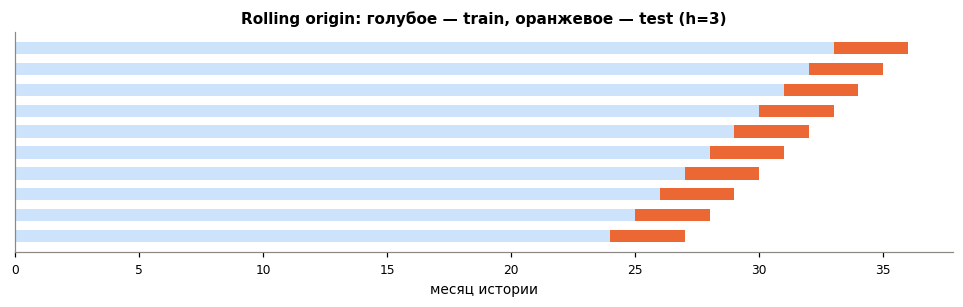

In [2]:
fig, ax = plt.subplots(figsize=(11, 2.6))
for k, t in enumerate(range(C.MIN_TRAIN, 36 - C.HORIZON + 1)):
    ax.barh(k, t, color="#cde2fb", height=0.6); ax.barh(k, C.HORIZON, left=t, color=ORANGE, height=0.6)
ax.set_yticks([]); ax.set_xlabel("месяц истории"); ax.grid(False)
ax.set_title("Rolling origin: голубое — train, оранжевое — test (h=3)"); plt.show()

### Почему не MAPE — на наших же данных

In [3]:
y = series[("SKU_0040", "MSK")].qty.to_numpy()[-6:]
print("факт SKU_0040, последние 6 мес.:", y, "-> MAPE делит на ноль\n")
fact = 100
for f in (0, 50, 150, 400):
    print(f"факт {fact}, прогноз {f:3d}: APE = {abs(f - fact) / fact:.0%}")
print("\nЗанизить можно максимум на 100%, завысить — без предела.")
print("Метод, оптимизирующий MAPE, будет систематически ЗАНИЖАТЬ — а занижение здесь = дефицит.")

факт SKU_0040, последние 6 мес.: [ 0.  0. 27.  0. 21.  0.] -> MAPE делит на ноль

факт 100, прогноз   0: APE = 100%
факт 100, прогноз  50: APE = 50%
факт 100, прогноз 150: APE = 50%
факт 100, прогноз 400: APE = 300%

Занизить можно максимум на 100%, завысить — без предела.
Метод, оптимизирующий MAPE, будет систематически ЗАНИЖАТЬ — а занижение здесь = дефицит.


| Метрика | Формула | Зачем | Где врёт |
|---|---|---|---|
| **Bias** | Σe / Σy, e = прогноз − факт | знак систематической ошибки — главное для поставок | плюсы и минусы гасят друг друга |
| **WAPE** | Σ\|e\| / Σy | понятна бизнесу, взвешена объёмом, живёт при нулях | в пуле доминирует крупный ряд (SKU_0018) |
| **MASE** | mean\|e\| / MAE наивного на train | безразмерна → сравнение рядов, выбор метода; <1 = лучше наивного | на прерывистых рядах поощряет занижение |
| **RMSSE** | то же на квадратах | для прерывистых: квадрат минимизируется **средним**, а MAE — **медианой**, которая там = 0 | чувствительна к выбросу |

## 2. Baseline: seasonal naive на всех рядах

рядов с backtest: 41 (у 4 коротких истории не хватает)
       wape   bias
mean  0.419  0.036
50%   0.158 -0.059
min   0.050 -0.158
max   5.067  3.067


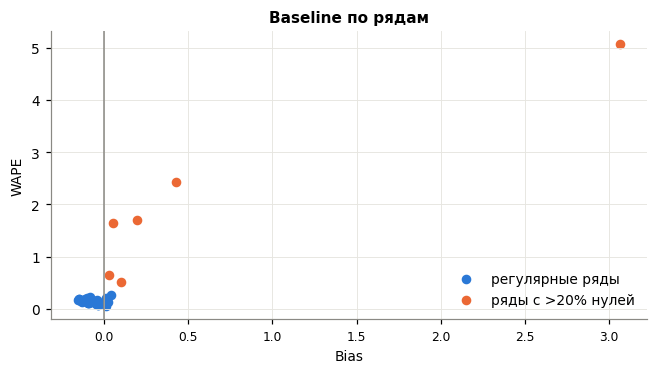

медианный bias регулярных рядов: -0.087


In [4]:
rows = []
for (sku, loc), g in series.items():
    if len(g) < C.MIN_TRAIN + C.HORIZON:
        continue
    bt = P.backtest_series(g.qty.to_numpy(), g.observed.to_numpy(), ["seasonal_naive"])
    rows.append({"sku": sku, "location": loc, "wape": M.wape(bt.y, bt.yhat), "bias": M.bias(bt.y, bt.yhat), "zeros": (g.qty == 0).mean()})
base = pd.DataFrame(rows)
print(f"рядов с backtest: {len(base)} (у 4 коротких истории не хватает)")
print(base[["wape", "bias"]].describe().round(3).loc[["mean", "50%", "min", "max"]].to_string())
fig, ax = plt.subplots(figsize=(7, 3.4))
inter = base.zeros > 0.2
ax.scatter(base.bias[~inter], base.wape[~inter], color=BLUE, s=28, label="регулярные ряды")
ax.scatter(base.bias[inter], base.wape[inter], color=ORANGE, s=28, label="ряды с >20% нулей")
ax.axvline(0, color=GRAY, lw=1); ax.set_xlabel("Bias"); ax.set_ylabel("WAPE"); ax.set_title("Baseline по рядам"); ax.legend(); plt.show()
print("медианный bias регулярных рядов:", round(base.bias[~inter].median(), 3))

segment
seasonal        27
regular          8
intermittent     6
short            4


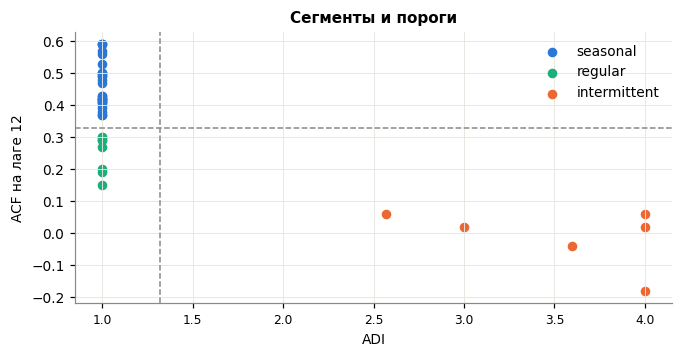

пограничные ряды (|ACF − порог| < 0.05):
     sku location  acf12  segment
SKU_0012      MSK   0.38 seasonal
SKU_0013      MSK   0.30  regular
SKU_0016      MSK   0.37 seasonal
SKU_0025      MSK   0.30  regular
SKU_0027      EKB   0.29  regular
SKU_0027      MSK   0.29  regular
SKU_0030      MSK   0.37 seasonal


In [5]:
seg = models.segment(clean)
print(seg.segment.value_counts().to_string())
fig, ax = plt.subplots(figsize=(7, 3.2))
full = seg[seg.n >= C.SHORT_HISTORY]
for name, color in [("seasonal", BLUE), ("regular", AQUA), ("intermittent", ORANGE)]:
    s_ = full[full.segment == name]; ax.scatter(s_.adi, s_.acf12, color=color, s=28, label=name)
ax.axvline(C.ADI_THRESHOLD, color=GRAY, lw=1, ls="--"); ax.axhline(C.SEASONAL_ACF_THRESHOLD, color=GRAY, lw=1, ls="--")
ax.set_xlabel("ADI"); ax.set_ylabel("ACF на лаге 12"); ax.set_title("Сегменты и пороги"); ax.legend(); plt.show()
print("пограничные ряды (|ACF − порог| < 0.05):")
print(full[(full.acf12 - C.SEASONAL_ACF_THRESHOLD).abs() < 0.05][["sku", "location", "acf12", "segment"]].to_string(index=False))

In [6]:
bt = P.backtest(clean, seg, P.CANDIDATES)
scores = P.score(bt, clean)
summary = P.summarize(scores)
chosen = P.select(summary)
summary["selected"] = [chosen[s_] == m for s_, m in zip(summary.segment, summary.method)]
print(summary.round(3).to_string(index=False))

     segment                method  n_series  mase  rmsse  wape   bias  selected
intermittent           croston_sba         6 1.138  0.740 1.372 -0.121      True
intermittent               mean_12         6 1.202  0.772 1.453  0.131     False
intermittent        seasonal_naive         6 1.263  1.007 1.705  0.339     False
intermittent                   tsb         6 1.158  0.745 1.436  0.165     False
     regular      moving_average_6         8 1.542  1.342 0.247 -0.026     False
     regular        seasonal_naive         8 1.188  1.107 0.195 -0.046      True
     regular          seasonal_ses         8 1.164  1.094 0.203  0.018     False
     regular                   ses         8 1.416  1.224 0.220 -0.010     False
    seasonal        seasonal_naive        27 1.067  1.013 0.135 -0.100     False
    seasonal seasonal_naive_growth        27 0.990  0.937 0.128 -0.046      True
    seasonal          seasonal_ses        27 1.004  0.941 0.139 -0.070     False
    seasonal                

In [7]:
print(scores[scores.sku == "SKU_0009"][["method", "mase", "rmsse", "bias"]].round(3).to_string(index=False))
g = series[("SKU_0009", "MSK")]
print("\n2024:", g.qty.to_numpy()[12:24].astype(int)); print("2025:", g.qty.to_numpy()[24:36].astype(int))

        method  mase  rmsse  bias
   croston_sba 1.177  0.725 0.943
       mean_12 1.133  0.708 0.776
seasonal_naive 0.288  0.309 0.102
           tsb 1.078  0.688 0.473

2024: [ 0  0  0  0  0  6  0  8  0  0  0 12]
2025: [10  0  0  0  0  6  0  7  0  0  0  0]


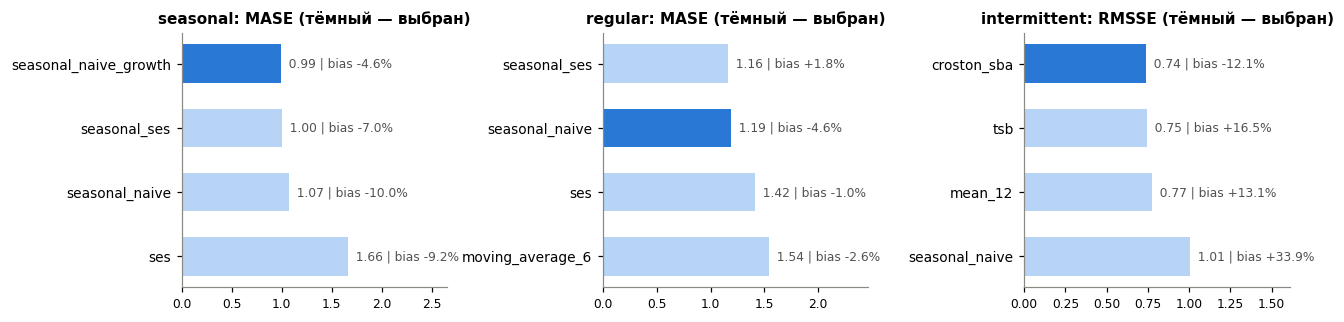

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, segname, metric in zip(axes, ["seasonal", "regular", "intermittent"], ["mase", "mase", "rmsse"]):
    s_ = summary[summary.segment == segname].sort_values(metric)
    colors = [BLUE if sel else "#b7d3f6" for sel in s_.selected]
    ax.barh(s_.method, s_[metric], color=colors, height=0.6)
    for yy, (v, b) in enumerate(zip(s_[metric], s_.bias)):
        ax.text(v, yy, f"  {v:.2f} | bias {b:+.1%}", va="center", fontsize=8, color="#52514e")
    ax.set_title(f"{segname}: {metric.upper()} (тёмный — выбран)"); ax.set_xlim(0, s_[metric].max() * 1.6); ax.grid(False); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Тюнинг

In [9]:
from demand_forecasting.models import _seasonal_indices, _ses_level
def seasonal_ses_fixed(alpha):
    def f(y, h):
        idx = _seasonal_indices(y); pos = np.arange(len(y)) % 12
        level, _ = _ses_level(y / idx[pos], alpha)
        return level * idx[(len(y) + np.arange(h)) % 12]
    return f
rows = []
seasonal_keys = [tuple(k) for k in seg[seg.segment == "seasonal"][D.SERIES].to_numpy()]
for alpha in (0.05, 0.1, 0.2, 0.3, 0.5, 0.8):
    models.REGISTRY["_tmp"] = seasonal_ses_fixed(alpha)
    e, a, v = [], 0.0, 0.0
    for k in seasonal_keys:
        g = series[k]; b = P.backtest_series(g.qty.to_numpy(), g.observed.to_numpy(), ["_tmp"])
        e.append((b.yhat - b.y).abs().sum() / b.y.sum()); a += (b.yhat - b.y).sum(); v += b.y.sum()
    rows.append({"alpha": alpha, "wape_mean": np.mean(e), "bias": a / v})
models.REGISTRY.pop("_tmp")
print(pd.DataFrame(rows).round(4).to_string(index=False))

 alpha  wape_mean    bias
  0.05     0.1447 -0.1521
  0.10     0.1288 -0.1062
  0.20     0.1246 -0.0778
  0.30     0.1275 -0.0669
  0.50     0.1361 -0.0540
  0.80     0.1526 -0.0422


## Итоговый прогноз

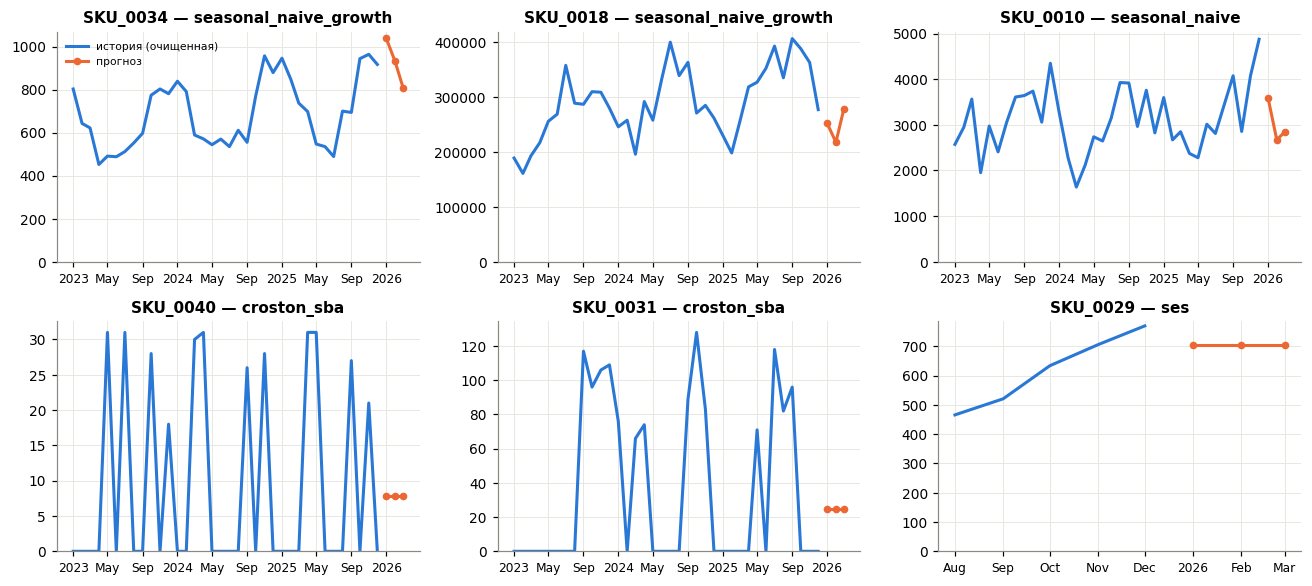

In [10]:
seg["method"] = seg.segment.map(chosen)
fig, axes = plt.subplots(2, 3, figsize=(12, 5.4))
show = [("SKU_0034", "MSK"), ("SKU_0018", "MSK"), ("SKU_0010", "MSK"), ("SKU_0040", "MSK"), ("SKU_0031", "MSK"), ("SKU_0029", "MSK")]
for ax, k in zip(axes.ravel(), show):
    g = series[k]; method = seg.set_index(D.SERIES).loc[k, "method"]
    f = models.forecast(method, g.qty.to_numpy(), C.HORIZON)
    t = g.period.dt.to_timestamp(); tf = pd.period_range(g.period.max() + 1, periods=C.HORIZON, freq="M").to_timestamp()
    ax.plot(t, g.qty, color=BLUE, label="история (очищенная)"); ax.plot(tf, f, color=ORANGE, marker="o", ms=4, label="прогноз")
    ax.set_title(f"{k[0]} — {method}"); ax.set_ylim(0)
axes[0, 0].legend(fontsize=7); plt.tight_layout(); plt.show()